In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df =  pd.read_csv("amz_uk_price_prediction_dataset.csv")
df.head(3)

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers


**Part 1: Understanding Product Categories**

Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

1. Frequency Tables:

- Generate a frequency table for the product category.

- Which are the top 5 most listed product categories?

2. Visualizations:

- Display the distribution of products across different categories using a bar chart. If you face problems understanding the chart, do it for a subset of top categories.
- For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

In [ ]:
category_freq = df['category'].value_counts()
category_freq

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978
...,...
Motorbike Chassis,107
Alexa Built-In Devices,107
Plugs,107


In [ ]:
top_5 = category_freq.head(5)
top_5

,count
category,
Sports & Outdoors,836265
Beauty,19312
"Handmade Clothing, Shoes & Accessories",19229
Bath & Body,19092
Birthday Gifts,18978


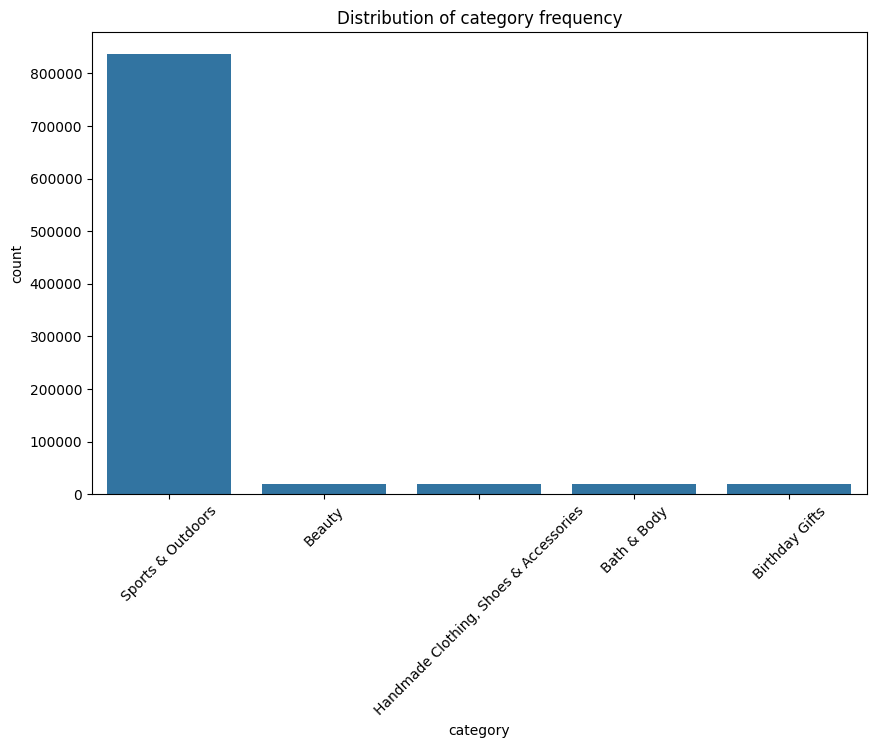

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_5)
plt.title("Distribution of category frequency")
plt.xticks(rotation=45) #changes the naming angle at the x-axis
plt.show() #plt.yticks for y-axis

#changing title on x-axis plt.xlable(name of column on chart)

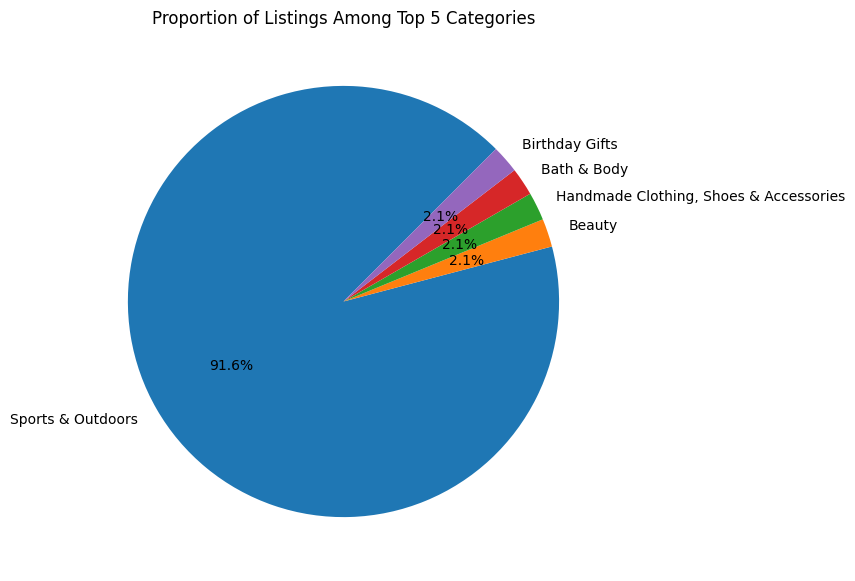

In [ ]:
plt.figure(figsize=(7,7))
top_5.plot(kind='pie', autopct='%1.1f%%', startangle=45)
plt.title("Proportion of Listings Among Top 5 Categories")
plt.ylabel("")
plt.show()

**Part 2: Delving into Product Pricing**

**Business Question**: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

1. **Measures of Centrality**:

- Calculate the mean, median, and mode for the price of products.
- What's the average price point of products - listed? How does this compare with the most common price point (mode)?

2. **Measures of Dispersion**:

- Determine the variance, standard deviation, range, and interquartile range for product price.
- How varied are the product prices? Are there any indicators of a significant spread in prices?

3. **Visualizations**:

- Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. If its hard to read these diagrams, think why this is, and explain how it could be solved..
- Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers in product pricing.


In [ ]:
#Measures of Centrality:

mean = df['price'].mean().round(2)
median = df['price'].median()
mode = df['price'].mode()[0]
print("mean:", mean, "|", "median: ", median, "|", "mode: ", mode)

mean: 89.24 | median:  19.09 | mode:  9.99


In [ ]:
#Measures of Dispersion
variance = df['price'].var()

std = df['price'].std()

p_range = df['price'].max() - df['price'].min()

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

print("variance: ", variance, "|", "std: ", std, "|", "price range: ", p_range, "|", "IQR: ",IQR)

variance:  119445.48532256528 | std:  345.60886175352226 | price range:  100000.0 | IQR:  36.0


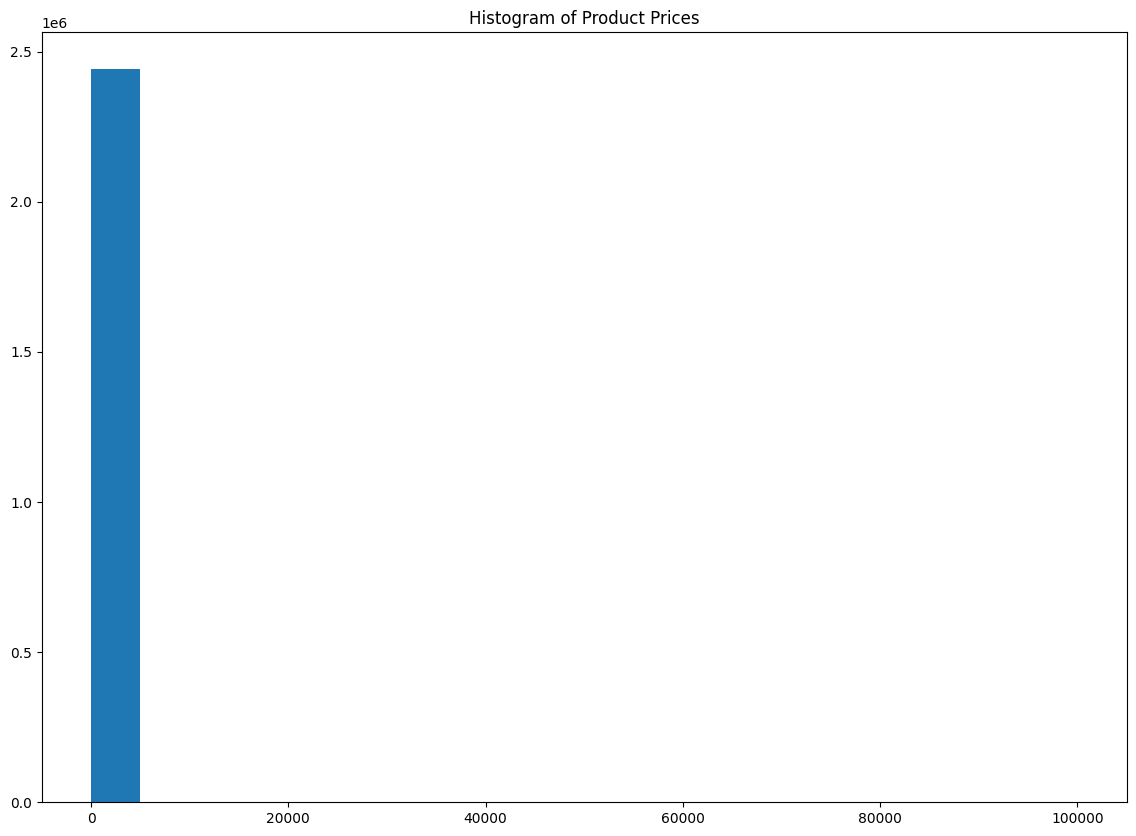

In [ ]:
#Visualizations:
plt.figure(figsize=(14,10))
plt.hist(df['price'], bins=20)
plt.title("Histogram of Product Prices")
plt.show()

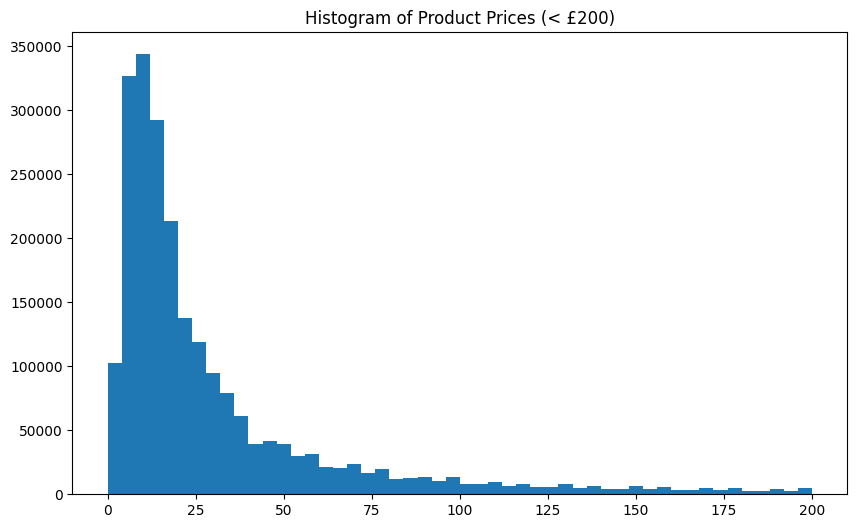

In [ ]:
#removes outliers by filtering
plt.figure(figsize=(10,6))
plt.hist(df[df['price'] < 200]['price'], bins=50)
plt.title("Histogram of Product Prices (< £200)")
plt.show()

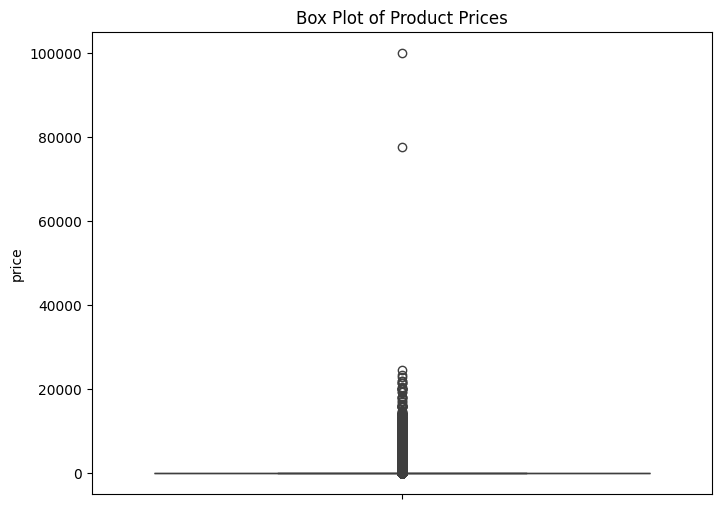

In [ ]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df['price'])
plt.title("Box Plot of Product Prices")
plt.show()

**Part 3: Unpacking Product Ratings**

**Business Question**: How do customers rate products on Amazon UK, and are there any patterns or tendencies in the ratings?

1. **Measures of Centrality**:

- Calculate the mean, median, and mode for the rating of products.
- How do customers generally rate products? Is there a common trend?

2. **Measures of Dispersion:**

- Determine the variance, standard deviation, and interquartile range for product rating.
- Are the ratings consistent, or is there a wide variation in customer feedback?

3. **Shape of the Distribution:**

- Calculate the skewness and kurtosis for the rating column.
- Are the ratings normally distributed, or do they lean towards higher or lower values?

4. **Visualizations:**

- Plot a histogram to visualize the distribution of product ratings. Is there a specific rating that is more common?

In [ ]:
#Measures of Centrality:

mean_stars = df['stars'].mean()
median_stars = df['stars'].median()
mode_stars = df['stars'].mode()[0]

print("mean: ", mean_stars,"|", "median: ", median_stars, "|", "mode: ", mode_stars)

mean:  2.152836472966065 | median:  0.0 | mode:  0.0


In [ ]:
#Measures of Dispersion:

variance_s = df['stars'].var()

std_s = df['stars'].std()

Q1 = df['stars'].quantile(0.25)
Q3 = df['stars'].quantile(0.75)
IQR_s = Q3 - Q1

print("variance: ", variance_s, "std: ", std_s,"IQR: ", IQR_s)

variance:  4.81743402976196 std:  2.1948653785054697 IQR:  4.4


In [ ]:
#Shape of the Distribution:

skewness = df['stars'].skew().round(2)
kurtosis = df['stars'].kurtosis().round(2)

print("skweness: ", skewness, "|", "kurtois: ", kurtosis)

skweness:  0.08 | kurtois:  -1.93


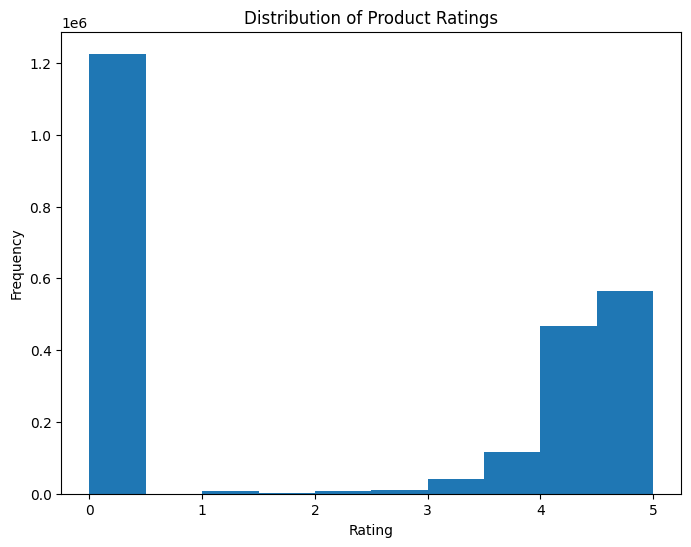

In [ ]:
#Visualizations:
plt.figure(figsize=(8,6))
plt.hist(df['stars'], bins=10)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()